Imports & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/processed/hr_cleaned.csv')
print("Shape:", df.shape)
print("Attrition dtype:", df['Attrition'].dtype)

Shape: (1470, 31)
Attrition dtype: int64


Encode Target Column

In [3]:
# Encode target if not already done
if df['Attrition'].dtype == object or df['Attrition'].dtype == str:
    df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print("Attrition value counts:")
print(df['Attrition'].value_counts())

Attrition value counts:
Attrition
0    1233
1     237
Name: count, dtype: int64


Encode Categorical Features

In [4]:
cat_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
print("Categorical columns to encode:", cat_cols)

# Label encode all categorical columns
le = LabelEncoder()
df_encoded = df.copy()

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print("\nAll dtypes after encoding:")
print(df_encoded.dtypes.value_counts())
print("\nShape:", df_encoded.shape)

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

All dtypes after encoding:
int64    31
Name: count, dtype: int64

Shape: (1470, 31)


 Feature Importance via Correlation

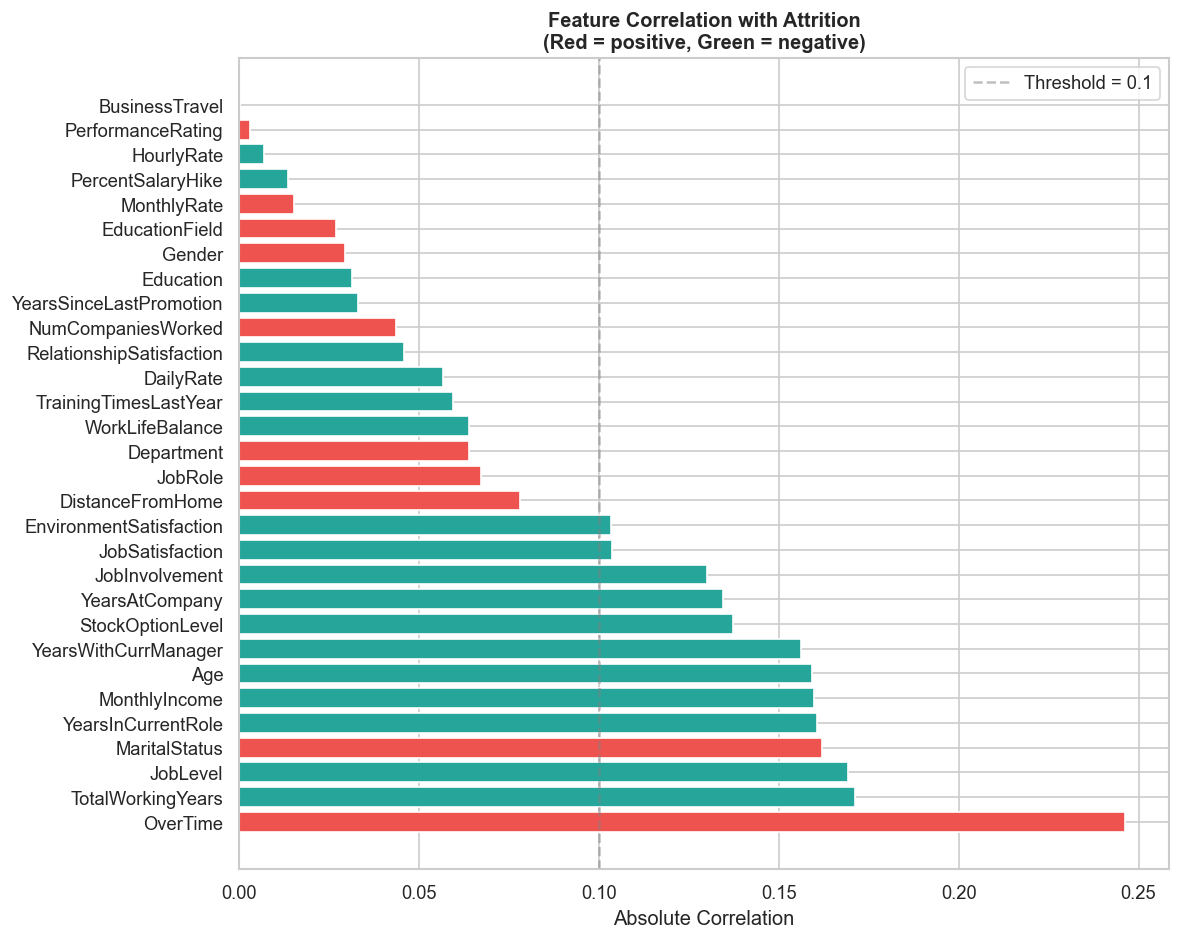


Top 10 correlated features:
OverTime                0.246118
TotalWorkingYears       0.171063
JobLevel                0.169105
MaritalStatus           0.162070
YearsInCurrentRole      0.160545
MonthlyIncome           0.159840
Age                     0.159205
YearsWithCurrManager    0.156199
StockOptionLevel        0.137145
YearsAtCompany          0.134392
Name: Attrition, dtype: float64


In [5]:
# Correlation of all features with Attrition
corr_with_target = df_encoded.corr()['Attrition'].drop('Attrition')
corr_sorted = corr_with_target.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#EF5350' if corr_with_target[col] > 0 else '#26A69A' 
          for col in corr_sorted.index]
ax.barh(corr_sorted.index, corr_sorted.values, color=colors, edgecolor='white')
ax.set_title('Feature Correlation with Attrition\n(Red = positive, Green = negative)', 
             fontweight='bold')
ax.set_xlabel('Absolute Correlation')
ax.axvline(x=0.1, color='gray', linestyle='--', alpha=0.5, label='Threshold = 0.1')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/09_feature_correlation.png', bbox_inches='tight')
plt.show()

print("\nTop 10 correlated features:")
print(corr_sorted.head(10))

 Chi-Square Test for Categorical Features

In [6]:
# Chi-square test: checks if categorical feature is statistically related to Attrition
cat_cols_orig = ['BusinessTravel', 'Department', 'EducationField',
                 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

chi2_results = []
for col in cat_cols_orig:
    ct = pd.crosstab(df[col], df['Attrition'])
    chi2, p, dof, _ = chi2_contingency(ct)
    chi2_results.append({'Feature': col, 'Chi2': round(chi2, 2), 'p-value': round(p, 4),
                         'Significant': 'Yes ' if p < 0.05 else 'No '})

chi2_df = pd.DataFrame(chi2_results).sort_values('Chi2', ascending=False)
print("Chi-Square Test Results:")
print(chi2_df.to_string(index=False))

Chi-Square Test Results:
       Feature  Chi2  p-value Significant
      OverTime 87.56   0.0000        Yes 
       JobRole 86.19   0.0000        Yes 
 MaritalStatus 46.16   0.0000        Yes 
BusinessTravel 24.18   0.0000        Yes 
EducationField 16.02   0.0068        Yes 
    Department 10.80   0.0045        Yes 
        Gender  1.12   0.2906         No 


Select Final Features

In [7]:
# Drop weak features (correlation < 0.05 with target)
weak_features = corr_sorted[corr_sorted < 0.05].index.tolist()
print("Weak features to drop:", weak_features)

df_final = df_encoded.drop(columns=weak_features)
print("\nShape after dropping weak features:", df_final.shape)
print("Remaining features:", df_final.columns.tolist())

Weak features to drop: ['RelationshipSatisfaction', 'NumCompaniesWorked', 'YearsSinceLastPromotion', 'Education', 'Gender', 'EducationField', 'MonthlyRate', 'PercentSalaryHike', 'HourlyRate', 'PerformanceRating', 'BusinessTravel']

Shape after dropping weak features: (1470, 20)
Remaining features: ['Age', 'Attrition', 'DailyRate', 'Department', 'DistanceFromHome', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'OverTime', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager']


Train-Test Split

In [8]:
X = df_final.drop('Attrition', axis=1)
y = df_final['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train set:", X_train.shape, "| Attrition rate:", round(y_train.mean()*100, 1), "%")
print("Test set: ", X_test.shape,  "| Attrition rate:", round(y_test.mean()*100, 1), "%")

Train set: (1176, 19) | Attrition rate: 16.2 %
Test set:  (294, 19) | Attrition rate: 16.0 %


Handle Class Imbalance with SMOTE

In [9]:
print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())
print(f"\nTraining set size after SMOTE: {X_train_sm.shape}")

Before SMOTE:
Attrition
0    986
1    190
Name: count, dtype: int64

After SMOTE:
Attrition
0    986
1    986
Name: count, dtype: int64

Training set size after SMOTE: (1972, 19)


 Feature Scaling

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done!")
print("Train shape:", X_train_scaled.shape)
print("Test shape: ", X_test_scaled.shape)

Scaling done!
Train shape: (1972, 19)
Test shape:  (294, 19)


Save Everything for Phase 4

In [11]:
import pickle

# Save processed data as CSVs
X_train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_df  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

X_train_df.to_csv('../data/processed/X_train.csv', index=False)
X_test_df.to_csv('../data/processed/X_test.csv',   index=False)
pd.Series(y_train_sm).to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

# Save scaler for later use in Power BI / deployment
os.makedirs('../outputs/models', exist_ok=True)
with open('../outputs/models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names
feature_names = X_train.columns.tolist()
with open('../outputs/models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print(" All files saved!")
print("Features used in model:", feature_names)

 All files saved!
Features used in model: ['Age', 'DailyRate', 'Department', 'DistanceFromHome', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'OverTime', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager']


Summary (Markdown Cell)


## Phase 3 Summary — Feature Engineering

| Step | Action | Result |
|---|---|---|
| Encoding | Label encoded 7 categorical columns | All features numeric |
| Correlation | Removed features with < 0.05 correlation | Kept only meaningful features |
| Chi-square | Verified categorical significance | OverTime, MaritalStatus most significant |
| Train/Test split | 80/20 stratified split | Class balance maintained |
| SMOTE | Oversampled minority class | Balanced training set |
| Scaling | StandardScaler on all features | Ready for ML models |